# **Assignment 2**

In [19]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as datetime

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
sales = pd.read_csv('/content/drive/MyDrive/MSSP607/InternetSales.csv', encoding='latin-1')

/tmp/ipython-input-3421444000.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv('/content/drive/MyDrive/MSSP607/InternetSales.csv', encoding='latin-1')


1.The Internet sales of Adventure Works by year of each Country Region

' Year CountryRegion  SalesAmount\n 2010            AU    20,909.78\n 2010            CA     3,578.27\n 2010            FR     3,399.99\n 2010            GB       699.10\n 2010            US    14,833.90\n 2011            AU 2,563,732.25\n 2011            CA   571,571.80\n 2011            DE   520,500.16\n 2011            FR   410,845.33\n 2011            GB   550,591.22\n 2011            US 2,458,285.17\n 2012            AU 2,128,407.46\n 2012            CA   307,604.52\n 2012            DE   608,657.98\n 2012            FR   648,065.54\n 2012            GB   712,700.96\n 2012            US 1,437,048.73\n 2013            AU 4,339,443.38\n 2013            CA 1,085,632.65\n 2013            DE 1,761,876.36\n 2013            FR 1,578,511.80\n 2013            GB 2,124,007.29\n 2013            US 5,462,078.86\n 2014            AU     8,507.72\n 2014            CA     9,457.62\n 2014            DE     3,277.83\n 2014            FR     3,195.06\n 2014            GB     3,713.64\n 2014        

    Year CountryRegion   SalesAmount
0   2010            AU  2.090978e+04
1   2010            CA  3.578270e+03
2   2010            FR  3.399990e+03
3   2010            GB  6.990982e+02
4   2010            US  1.483390e+04
5   2011            AU  2.563732e+06
6   2011            CA  5.715718e+05
7   2011            DE  5.205002e+05
8   2011            FR  4.108453e+05
9   2011            GB  5.505912e+05
10  2011            US  2.458285e+06
11  2012            AU  2.128407e+06
12  2012            CA  3.076045e+05
13  2012            DE  6.086580e+05
14  2012            FR  6.480655e+05
15  2012            GB  7.127010e+05
16  2012            US  1.437049e+06
17  2013            AU  4.339443e+06
18  2013            CA  1.085633e+06
19  2013            DE  1.761876e+06
20  2013            FR  1.578512e+06
21  2013            GB  2.124007e+06
22  2013            US  5.462079e+06
23  2014            AU  8.507720e+03
24  2014            CA  9.457620e+03
25  2014            DE  3.277830e+03
2

<Figure size 1000x600 with 0 Axes>

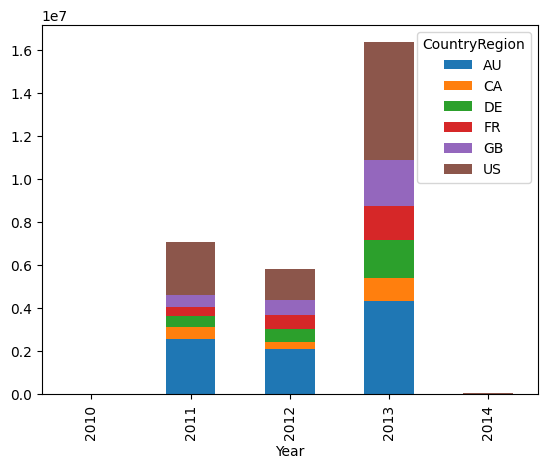

In [21]:
#category by year
sales['OrderDateKey'] = pd.to_datetime(sales['OrderDateKey'], format='%Y%m%d')
Year = sales.OrderDateKey.dt.year
sales['Year'] = sales['OrderDateKey'].dt.year
#category by country region
sales['CountryRegion'] = sales['CountryRegionCode']
#sum the amount of internet sales
sales_summary = sales.groupby(['Year', 'CountryRegion'])['SalesAmount'].sum().reset_index()
display(sales_summary.to_string(index=False, float_format='{:,.2f}'.format))
print(sales_summary)
plt.figure(figsize=(10,6))
pivot_table = sales_summary.pivot(index='Year', columns='CountryRegion', values='SalesAmount')
pivot_table.plot(kind='bar', stacked=True)
plt.show()


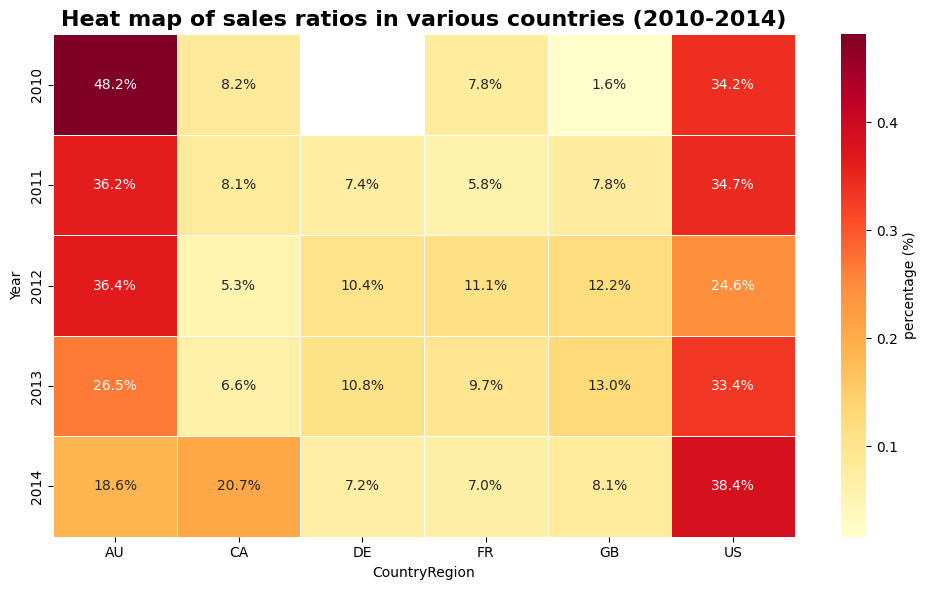

In [22]:
#each country's proportion in internet sales in every year
sales_by_year = sales.groupby(['Year', 'CountryRegion'])['SalesAmount'].sum().reset_index()

# Calculate the total sales for each year
yearly_total_sales = sales_by_year.groupby('Year')['SalesAmount'].transform('sum')

# Calculate the proportion of sales for each country within each year
sales_by_year['SalesProportion'] = sales_by_year['SalesAmount'] / yearly_total_sales

# Create the pivot table using the calculated proportion
pivot_table = sales_by_year.pivot(index='Year', columns='CountryRegion', values='SalesProportion')

#visualization
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1%', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'percentage (%)'})
plt.title('Heat map of sales ratios in various countries (2010-2014)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Sales Predictions for 2014, 2015, and 2016:


,2014_pred,2015_pred,2016_pred,growth_trend
AU,4.786239e+06,5.674094e+06,6.561950e+06,8.878556e+05
CA,1.168997e+06,1.426028e+06,1.683058e+06,2.570304e+05
DE,2.205054e+06,2.825742e+06,3.446431e+06,6.206881e+05
FR,2.046807e+06,2.630641e+06,3.214474e+06,5.838332e+05
GB,2.702516e+06,3.489224e+06,4.275932e+06,7.867080e+05
US,6.122931e+06,7.624828e+06,9.126725e+06,1.501897e+06


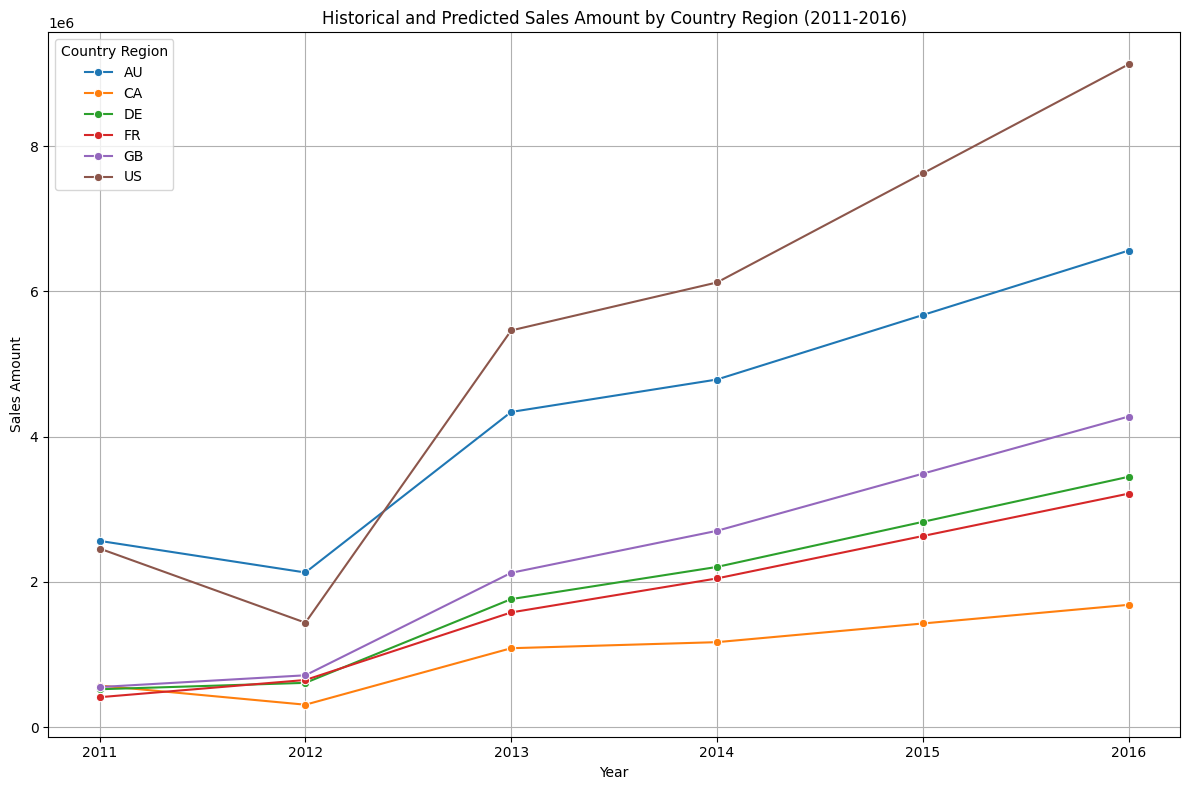

In [23]:
#forecast
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sales data for years 2011, 2012, and 2013
sales_by_year = sales.groupby(['Year', 'CountryRegion'])['SalesAmount'].sum().reset_index()
valid_years = [2011, 2012, 2013]
sales_valid = sales_by_year[sales_by_year['Year'].isin(valid_years)]

predictions = {}
future_years = np.array([2014, 2015, 2016]).reshape(-1, 1)

for country in sales_valid['CountryRegion'].unique():
    country_data = sales_valid[sales_valid['CountryRegion'] == country].sort_values('Year')

    if len(country_data) >= 2:
        X = country_data['Year'].values.reshape(-1, 1)
        y = country_data['SalesAmount'].values
        # Train a simple linear regression model
        model = LinearRegression()
        model.fit(X, y)

        # Make predictions for future years
        future_pred = model.predict(future_years)

        # Store predictions and growth trend
        predictions[country] = {
            '2014_pred': future_pred[0],
            '2015_pred': future_pred[1],
            '2016_pred': future_pred[2],
            'growth_trend': model.coef_[0] # The coefficient represents the linear growth per year
        }
    else:
        print(f"Not enough data for {country} to train a model.")

# Display the predictions
predictions_df = pd.DataFrame(predictions).T
print("Sales Predictions for 2014, 2015, and 2016:")
display(predictions_df)

# Prepare data for plotting historical and predicted sales
historical_sales_plot = sales_by_year[sales_by_year['Year'].isin([2011, 2012, 2013])]

# Reshape predictions_df for merging
predictions_melted = predictions_df.reset_index().melt(id_vars='index', value_vars=['2014_pred', '2015_pred', '2016_pred'], var_name='Year_Pred', value_name='SalesAmount')
predictions_melted['Year'] = predictions_melted['Year_Pred'].str.replace('_pred', '').astype(int)
predictions_melted = predictions_melted.rename(columns={'index': 'CountryRegion'})[['Year', 'CountryRegion', 'SalesAmount']]

# Combine historical and predicted data
combined_sales = pd.concat([historical_sales_plot, predictions_melted], ignore_index=True)

# Sort by Year and CountryRegion for plotting
combined_sales = combined_sales.sort_values(by=['CountryRegion', 'Year'])

# Visualization
plt.figure(figsize=(12, 8))
sns.lineplot(data=combined_sales, x='Year', y='SalesAmount', hue='CountryRegion', marker='o')
plt.xlabel('Year')
plt.ylabel('Sales Amount')
plt.title('Historical and Predicted Sales Amount by Country Region (2011-2016)')
plt.grid(True)
plt.legend(title='Country Region')
plt.xticks(combined_sales['Year'].unique())
plt.tight_layout()
plt.show()

2.Generate summary satistics including min, max, and sd for Yearly Income, Genderby Country Regions

In [24]:
yearly_income = sales.groupby(['CountryRegion','Gender'])['YearlyIncome'].agg(['min','max','std']).reset_index()
yearly_income

,CountryRegion,Gender,min,max,std
0,AU,F,10000,160000,30613.956169
1,AU,M,10000,170000,32550.778171
2,CA,F,10000,170000,19435.158438
3,CA,M,10000,170000,22702.851581
4,DE,F,10000,130000,37622.814569
5,DE,M,10000,130000,37487.619366
6,FR,F,10000,110000,28421.836245
7,FR,M,10000,110000,28665.660622
8,GB,F,10000,170000,51130.689140
9,GB,M,10000,170000,50963.707551


<Axes: xlabel='CountryRegion', ylabel='SalesAmount'>

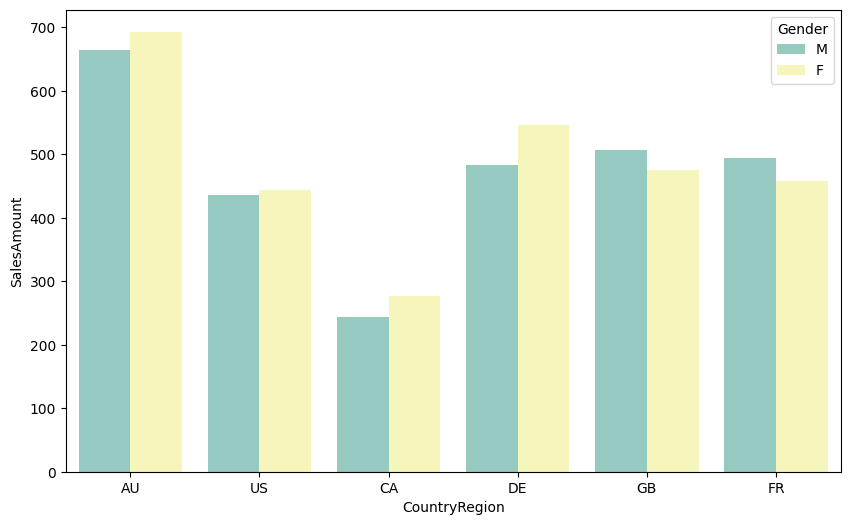

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(data=sales,
    x='CountryRegion',
    y='SalesAmount',
    hue='Gender',
    palette='Set3',
    errorbar=None)

3.Average price of the product category that generates the most sales

In [26]:
product_sales = sales.groupby(['ProductKey'])['SalesAmount'].sum().reset_index()
product_sales = product_sales.sort_values(by='SalesAmount', ascending=False)
top10_products = product_sales.head(10)
top10_products


product_names = sales[['ProductKey', 'EnglishProductName']].drop_duplicates()
top10_with_names = top10_products.merge(product_names, on='ProductKey', how='left')
top10_with_names[['ProductKey', 'EnglishProductName', 'SalesAmount']]


,ProductKey,EnglishProductName,SalesAmount
0,312,"Road-150 Red, 48",1205876.99
1,310,"Road-150 Red, 62",1202298.72
2,313,"Road-150 Red, 52",1080637.54
3,314,"Road-150 Red, 56",1055589.65
4,311,"Road-150 Red, 44",1005493.87
5,361,"Mountain-200 Black, 42",979960.73
6,353,"Mountain-200 Silver, 38",979035.78
7,363,"Mountain-200 Black, 46",961600.81
8,359,"Mountain-200 Black, 38",954715.84
9,357,"Mountain-200 Silver, 46",930315.99


/tmp/ipython-input-1794221795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_products,


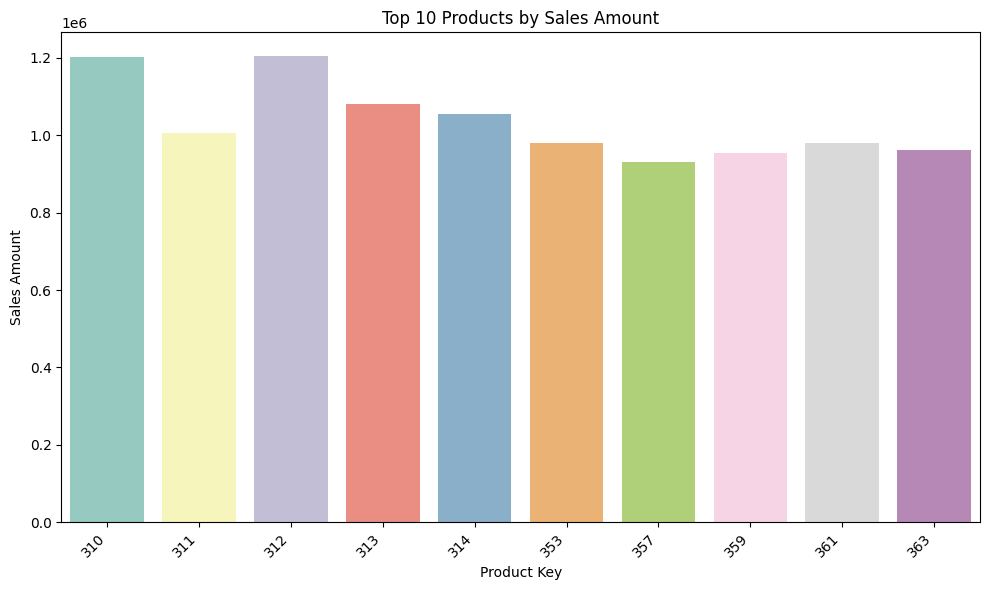

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=top10_products,
    x='ProductKey',
    y='SalesAmount',
    palette='Set3',
    errorbar=None)
plt.title('Top 10 Products by Sales Amount')
plt.xlabel('Product Key')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

4.Owning a home make a difference in sales?

In [28]:
home = sales.groupby(['HouseOwnerFlag']).agg({'SalesAmount': ['count','sum','mean','std']}).reset_index()
home

HouseOwnerFlag SalesAmount                                      
                       count           sum        mean         std
0              0       18699  8.973327e+06  479.882744  924.841795
1              1       41699  2.038535e+07  488.869033  930.118780

/tmp/ipython-input-3307376322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=home,


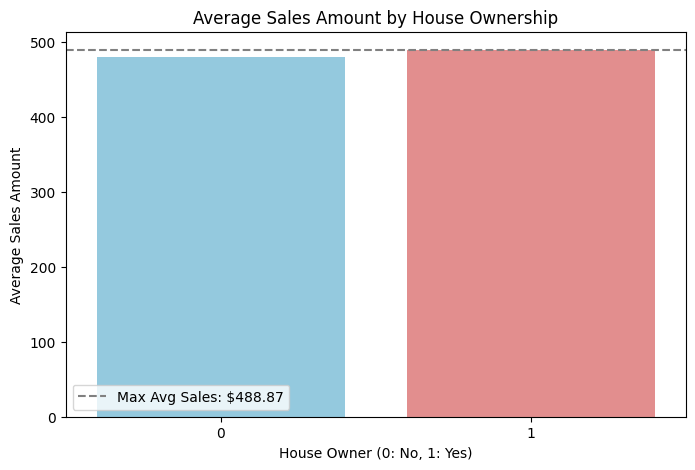

In [29]:
plt.figure(figsize=(8, 5)) # Provide figsize as a tuple
sns.barplot(data=home,
    x='HouseOwnerFlag',
    y=('SalesAmount', 'mean'), # Use the 'mean' from the multi-level column
    palette=['skyblue', 'lightcoral'], # Use a list of colors for different bars
    errorbar=None
)

# Add a horizontal line at the maximum average sales amount
max_sales_mean = home[('SalesAmount', 'mean')].max()
plt.axhline(y=max_sales_mean, color='gray', linestyle='--', label=f'Max Avg Sales: ${max_sales_mean:.2f}')

plt.title('Average Sales Amount by House Ownership')
plt.xlabel('House Owner (0: No, 1: Yes)')
plt.ylabel('Average Sales Amount')
plt.legend() # Show the legend for the horizontal line
plt.show()

In [30]:
#Test:SalesAmount of EnglishProductName = Mountain-200 Black, 46
product_name = 'Mountain-200 Black, 46'
sales_of_product = sales[sales['EnglishProductName'] == product_name]
total_sales_of_product = sales_of_product['SalesAmount'].sum()

print(f"Total sales amount for '{product_name}': ${total_sales_of_product:.2f}")

Total sales amount for 'Mountain-200 Black, 46': $1373469.55
